In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv('IMDB_Dataset.csv')


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Converting labels to numbers


In [3]:
dataset['sentiment'] = dataset['sentiment'].map({
    "negative": 0,
    "positive": 1
})

dataset.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [4]:
X = dataset['review']
y = dataset['sentiment']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

Vectorizing the reviews to bag of words

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

In [37]:
vectorizer = CountVectorizer(
    max_features=5000,   # limit vocabulary
    stop_words="english"
)

X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow  = vectorizer.transform(X_test)


In [38]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train_bow, y_train)

LinearRegression()

In [39]:
y_pred_scores = regressor.predict(X_test_bow)


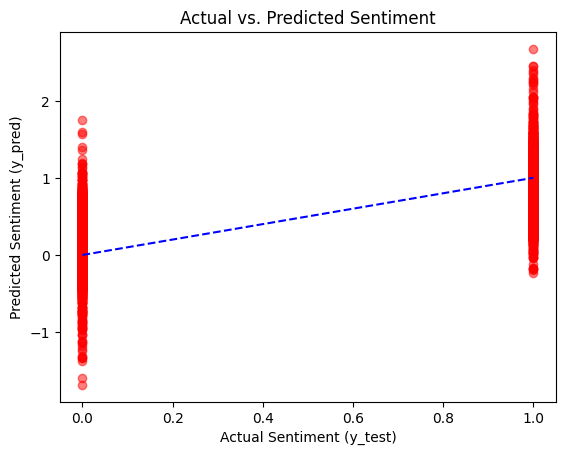

In [40]:
plt.scatter(y_test, y_pred, color='red', alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='blue', linestyle='--')
plt.xlabel('Actual Sentiment (y_test)')
plt.ylabel('Predicted Sentiment (y_pred)')
plt.title('Actual vs. Predicted Sentiment')
plt.show()

In [41]:
y_pred_labels = (y_pred_scores >= 0.5).astype(int)


In [42]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

MSE: 0.13695942786677873


In [45]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred_labels)*100
print("Accuracy:", accuracy)


Accuracy: 85.97


In [44]:
def predict_sentiment(text):
    vector = vectorizer.transform([text])
    score = regressor.predict(vector)[0]
    sentiment = "Positive" if score >= 0.5 else "Negative"
    return score, sentiment

predict_sentiment("The music of the movie was pretty good")


(np.float64(0.5107369820090666), 'Positive')